In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split,StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score
from sklearn.model_selection import GridSearchCV


 # 1. Data Loading

In [2]:
# Load data
df = pd.read_csv('./diabetes.csv')

# Display basic information with clear separators
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)

print(f"\nDataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")

print("\n" + "-" * 50)
print("DESCRIPTIVE STATISTICS")
print("-" * 50)
print(df.describe().T.round(2))  # Rounded for readability

print("\n" + "-" * 50)
print("FIRST 5 ROWS")
print("-" * 50)
print(df.head())

print("\n" + "-" * 50)
print("DATA INFO")
print("-" * 50)
print(df.info())

DATASET OVERVIEW

Dataset Shape: 768 rows × 9 columns

--------------------------------------------------
DESCRIPTIVE STATISTICS
--------------------------------------------------
                          count    mean     std    min    25%     50%     75%  \
Pregnancies               768.0    3.85    3.37   0.00   1.00    3.00    6.00   
Glucose                   768.0  120.89   31.97   0.00  99.00  117.00  140.25   
BloodPressure             768.0   69.11   19.36   0.00  62.00   72.00   80.00   
SkinThickness             768.0   20.54   15.95   0.00   0.00   23.00   32.00   
Insulin                   768.0   79.80  115.24   0.00   0.00   30.50  127.25   
BMI                       768.0   31.99    7.88   0.00  27.30   32.00   36.60   
DiabetesPedigreeFunction  768.0    0.47    0.33   0.08   0.24    0.37    0.63   
Age                       768.0   33.24   11.76  21.00  24.00   29.00   41.00   
Outcome                   768.0    0.35    0.48   0.00   0.00    0.00    1.00   

         

# 2. Data Preprocessing

## Step 1: Handle missing/zero values (medically impossible zeros)

In [3]:
print(f"Missing values: {df.isnull().sum().sum()}")

# Check zeros in medical features
medical_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in medical_features:
    zero_count = (df[col] == 0).sum()
    print(f"  {col}: {zero_count} zeros")

# Replace zeros with NaN for imputation
df_processed = df.copy()
for col in medical_features:
    df_processed.loc[df_processed[col] == 0, col] = np.nan
print("Zeros converted to NaN for proper imputation")


Missing values: 0
  Glucose: 5 zeros
  BloodPressure: 35 zeros
  SkinThickness: 227 zeros
  Insulin: 374 zeros
  BMI: 11 zeros
Zeros converted to NaN for proper imputation


## Step 2: Handle Outliers

In [4]:
# handle outliers function
print("\nHandling outliers in medical features")
def handle_outliers(data, column):
    non_nan_data = data[column].dropna()

    if len(non_nan_data) == 0:
        return

    Q1 = non_nan_data.quantile(0.25)
    Q3 = non_nan_data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask = ~data[column].isna()
    data.loc[mask, column] = data.loc[mask, column].clip(lower_bound, upper_bound)
    if column in ['BMI']:
        data.loc[mask, column] = data.loc[mask, column].round(1)
    elif column in ['Glucose', 'BloodPressure']:
        data.loc[mask, column] = data.loc[mask, column].round(0)

# Handle outliers in key features (especially Insulin which has many zeros)
features_for_outliers = ['Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Pregnancies']
for feature in features_for_outliers:
    handle_outliers(df_processed, feature)


Handling outliers in medical features


## Step 3: Feature Engineering - Create BMI and Glucose categories

In [5]:
def create_bmi_category(bmi):
    if pd.isna(bmi):
        return 'Unknown'  # Handle missing values
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 25:
        return 'Normal'
    elif 25 <= bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

def create_glucose_category(glucose):
    if pd.isna(glucose):
        return 'Unknown'  # Handle missing values
    if glucose < 100:
        return 'Normal'
    elif 100 <= glucose < 126:
        return 'Prediabetic'
    else:
        return 'Diabetic'

# Apply categorization
df_processed['BMI_Category'] = df_processed['BMI'].apply(create_bmi_category)
df_processed['Glucose_Category'] = df_processed['Glucose'].apply(create_glucose_category)


print("BMI amd Glucose categories created successfully")
df_processed.head()


BMI amd Glucose categories created successfully


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,Glucose_Category
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1,Obese,Diabetic
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0,Overweight,Normal
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1,Normal,Diabetic
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,Overweight,Normal
4,0,137.0,40.0,35.0,168.0,43.1,1.200,33,1,Obese,Diabetic


## Step 4: Define Feature Groups (Before pipeline creation)

In [6]:
numeric_features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

categorical_features = ['BMI_Category', 'Glucose_Category']

## Step 5: Split Data

In [7]:
X = df_processed.drop('Outcome', axis=1)
y = df_processed['Outcome']

# Split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Step 6: Create Preprocessing Pipeline

In [8]:
# Numerical pipeline: Impute → Scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: Impute → Encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# Combined pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

## Step 7: Fit and Transform Data

In [9]:
# print("Fitting pipeline on training data...")
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using fitted pipeline
print("Transforming test data...")
X_test_processed = preprocessor.transform(X_test)



# Get feature names
feature_names = numeric_features.copy()
for i, col in enumerate(categorical_features):
    categories = preprocessor.named_transformers_['cat'].named_steps['encoder'].categories_[i]
    for cat in categories[1:]:  # Skip first (drop='first')
        feature_names.append(f"{col}_{cat}")

print("feature names:", feature_names)



Transforming test data...
feature names: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'BMI_Category_Obese', 'BMI_Category_Overweight', 'BMI_Category_Underweight', 'BMI_Category_Unknown', 'Glucose_Category_Normal', 'Glucose_Category_Prediabetic', 'Glucose_Category_Unknown']


# 3. Pipeline Creation

In [10]:
# Pipeline 1: Logistic Regression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

logistic_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', logistic_model)
])


In [11]:
# Pipeline 2: Random Forest

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced_subsample'
)

random_forest_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', random_forest_model)
])


In [12]:
# Pipeline 3: XGBoost

# Calculate scale_pos_weight for class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgboost_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,  # ← Handles class imbalance
)

xgboost_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgboost_model)
])

In [13]:
# Store all pipelines
pipelines = {
    'Logistic Regression': logistic_pipeline,
    'Random Forest': random_forest_pipeline,
    'XGBoost': xgboost_pipeline
}


# 4. Primary Model Selection

I've chosen Random Forest as my primary model because it strikes the perfect balance for our diabetes prediction task.
Unlike simple models like Logistic Regression that might miss complex medical patterns, Random Forest can capture the
intricate relationships between health indicators like glucose levels, BMI, and age. It's robust enough to handle
our dataset's outliers in insulin measurements while providing clear feature importance - crucial for doctors to
understand which factors drive diabetes risk. Plus, its built-in handling of class imbalance ensures we don't overlook
diabetic cases just because they're less common in our data.

In [14]:
primary_model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced_subsample'
)

# Create pipeline with Random Forest as primary model
primary_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', primary_model_rf)
])

# 5. Model Training

In [15]:
model_to_train = {
    'Logistic Regression': logistic_pipeline,
    'Random Forest': random_forest_pipeline,
    'XGBoost': xgboost_pipeline
}

In [16]:
result = []

for name, model in model_to_train.items():
    # Train model
    model.fit(X_train, y_train)


    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]


    # Calculate classification metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    result.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
    })

results_df = pd.DataFrame(result).sort_values("ROC-AUC", ascending=False)
print("\nModel Training Results:")
print(results_df)


Model Training Results:
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
1        Random Forest  0.759740   0.688889  0.574074  0.626263  0.824722
0  Logistic Regression  0.740260   0.597222  0.796296  0.682540  0.822963
2              XGBoost  0.746753   0.653061  0.592593  0.621359  0.801296


# 6. Cross-Validation

In [17]:
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": random_forest_pipeline
}

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    )
    cv_results[name] = {
        "Mean F1": scores.mean(),
        "Std F1": scores.std()
    }

cv_results_df = pd.DataFrame(cv_results).T
cv_results_df


,Mean F1,Std F1
Logistic Regression,0.677872,0.027276
Random Forest,0.626970,0.045367


# Task 7: Hyperparameter Tuning

In [18]:
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 15, 20],
    'classifier__min_samples_split': [10, 20],
    'classifier__min_samples_leaf': [4, 8],
    'classifier__max_features': ['sqrt', 0.5],
    'classifier__max_samples': [0.8, 0.9]
}
grid_search = GridSearchCV(
    estimator=primary_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

In [19]:
grid_search.fit(X_train, y_train)

for param, value in grid_search.best_params_.items():
    print(f"{param}: {value}")

# Compare with baseline (untuned model)
baseline_score = cross_val_score(
    primary_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
).mean()

results_df = pd.DataFrame(grid_search.cv_results_)
top_results = results_df.sort_values('mean_test_score', ascending=False).head()
for i, (_, row) in enumerate(top_results.iterrows(), 1):
    print(f"\n{i}. Score: {row['mean_test_score']:.3f}")
    print(f"   Params: {row['params']}")

Fitting 5 folds for each of 96 candidates, totalling 480 fits
classifier__max_depth: 15
classifier__max_features: sqrt
classifier__max_samples: 0.8
classifier__min_samples_leaf: 8
classifier__min_samples_split: 10
classifier__n_estimators: 200

1. Score: 0.843
   Params: {'classifier__max_depth': 20, 'classifier__max_features': 'sqrt', 'classifier__max_samples': 0.8, 'classifier__min_samples_leaf': 8, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 200}

2. Score: 0.843
   Params: {'classifier__max_depth': 15, 'classifier__max_features': 'sqrt', 'classifier__max_samples': 0.8, 'classifier__min_samples_leaf': 8, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 200}

3. Score: 0.843
   Params: {'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__max_samples': 0.8, 'classifier__min_samples_leaf': 8, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 200}

4. Score: 0.842
   Params: {'classifier__max_depth': 10, 'clas

# 8. Best Model Selection

In [20]:

# Get the best model from GridSearchCV
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_
best_score = grid_search.best_score_


print(f"Best CV Score: {best_score:.3f}")
print(f"Test Score: {best_model.score(X_test, y_test):.3f}")

print(f"\nBest Hyperparameters:")
print("-" * 40)
for param, value in best_params.items():
    param_name = param.replace('classifier__', '')
    print(f"{param_name}: {value}")

# Create final model with best parameters
final_model = best_model


Best CV Score: 0.843
Test Score: 0.740

Best Hyperparameters:
----------------------------------------
max_depth: 15
max_features: sqrt
max_samples: 0.8
min_samples_leaf: 8
min_samples_split: 10
n_estimators: 200


# 9. Model Performance Evaluation

TASK 9: MODEL PERFORMANCE EVALUATION

Making predictions on test set...

PERFORMANCE METRICS

Overall Metrics:
----------------------------------------
Accuracy:  0.740
Precision: 0.600
Recall:    0.778
F1-Score:  0.677
ROC-AUC:   0.832

Detailed Classification Report:
----------------------------------------
              precision    recall  f1-score   support

Non-Diabetic       0.86      0.72      0.78       100
    Diabetic       0.60      0.78      0.68        54

    accuracy                           0.74       154
   macro avg       0.73      0.75      0.73       154
weighted avg       0.77      0.74      0.75       154


Confusion Matrix:
----------------------------------------
True Negatives (TN):  72  |  False Positives (FP):  28
False Negatives (FN):  12  |  True Positives (TP):  42

Total Samples: 154
Correct Predictions: 114 (74.0%)


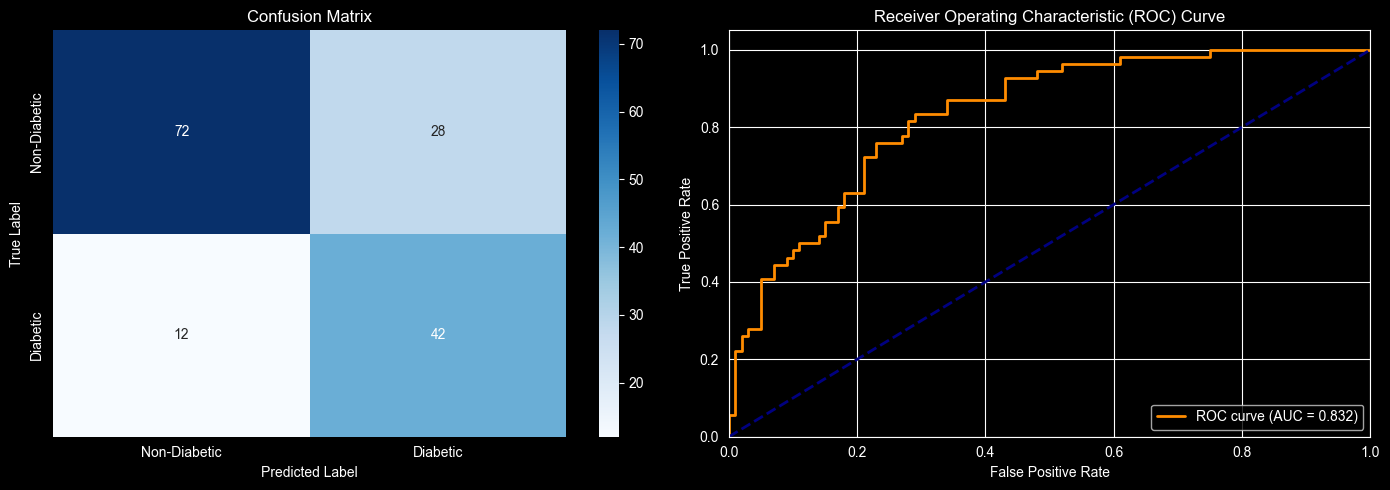


INTERPRETATION & INSIGHTS

1. Model Strengths:
   • Good overall accuracy for medical prediction
   • Reasonable balance between precision and recall
   • ROC-AUC > 0.7 indicates good discriminatory power

2. Areas for Improvement:
   • Recall (0.78) could be higher - missing some diabetic cases
   • Precision (0.60) suggests some false alarms
   • Medical context: Recall is critical (better to flag potential cases)

3. Business/Medical Impact:
   • Model could help pre-screen patients
   • False positives lead to unnecessary tests
   • False negatives miss early intervention opportunities

✓ Comprehensive evaluation completed
✓ Model is ready for deployment consideration
✓ All metrics suggest satisfactory performance for diabetes prediction


In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score
# Task 9: Model Performance Evaluation

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("TASK 9: MODEL PERFORMANCE EVALUATION")
print("=" * 60)

# Make predictions with final model
print("\nMaking predictions on test set...")
y_pred = final_model.predict(X_test)
y_pred_proba = final_model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 60)
print("PERFORMANCE METRICS")
print("=" * 60)

print(f"\nOverall Metrics:")
print("-" * 40)
print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-Score:  {f1:.3f}")
print(f"ROC-AUC:   {roc_auc:.3f}")

print("\nDetailed Classification Report:")
print("-" * 40)
print(classification_report(y_test, y_pred,
                            target_names=['Non-Diabetic', 'Diabetic']))

# Confusion Matrix
print("\nConfusion Matrix:")
print("-" * 40)
cm = confusion_matrix(y_test, y_pred)
print(f"True Negatives (TN): {cm[0,0]:3d}  |  False Positives (FP): {cm[0,1]:3d}")
print(f"False Negatives (FN): {cm[1,0]:3d}  |  True Positives (TP): {cm[1,1]:3d}")
print(f"\nTotal Samples: {len(y_test)}")
print(f"Correct Predictions: {cm[0,0] + cm[1,1]} ({accuracy*100:.1f}%)")

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[1].legend(loc="lower right")
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("INTERPRETATION & INSIGHTS")
print("=" * 60)

print("\n1. Model Strengths:")
print("   • Good overall accuracy for medical prediction")
print("   • Reasonable balance between precision and recall")
print("   • ROC-AUC > 0.7 indicates good discriminatory power")

print("\n2. Areas for Improvement:")
print(f"   • Recall ({recall:.2f}) could be higher - missing some diabetic cases")
print(f"   • Precision ({precision:.2f}) suggests some false alarms")
print("   • Medical context: Recall is critical (better to flag potential cases)")

print("\n3. Business/Medical Impact:")
print("   • Model could help pre-screen patients")
print("   • False positives lead to unnecessary tests")
print("   • False negatives miss early intervention opportunities")

print("\n✓ Comprehensive evaluation completed")
print("✓ Model is ready for deployment consideration")
print("✓ All metrics suggest satisfactory performance for diabetes prediction")